# 1. Motivation and Goal


link to the dataset from Kaggle: https://www.kaggle.com/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset

# 2. Import libraries and setup

In [88]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier



# 3. Data importing and Data ingestion

In [89]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahriarkabir/drug-discovery-virtual-screening-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/cholponzhakshylykova/.cache/kagglehub/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset/versions/1


In [90]:
os.listdir(path)

['drug_discovery_virtual_screening.csv']

In [91]:
# Load the dataset
df = pd.read_csv(os.path.join(path, "drug_discovery_virtual_screening.csv"))

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compound_id          2000 non-null   str    
 1   protein_id           2000 non-null   str    
 2   molecular_weight     2000 non-null   float64
 3   logp                 1940 non-null   float64
 4   h_bond_donors        2000 non-null   int64  
 5   h_bond_acceptors     2000 non-null   int64  
 6   rotatable_bonds      2000 non-null   int64  
 7   polar_surface_area   1940 non-null   float64
 8   compound_clogp       2000 non-null   float64
 9   protein_length       2000 non-null   int64  
 10  protein_pi           2000 non-null   float64
 11  hydrophobicity       1940 non-null   float64
 12  binding_site_size    2000 non-null   float64
 13  mw_ratio             2000 non-null   float64
 14  logp_pi_interaction  2000 non-null   float64
 15  binding_affinity     2000 non-null   float64
 16 

In [93]:
df.describe()

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
count,2000.000000,1940.000000,2000.000000,2000.000000,2000.00000,1940.000000,2000.000000,2000.00000,2000.000000,1940.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,456.772168,3.479480,1.961000,5.115000,5.96850,80.026470,2.813403,848.92600,6.460332,0.645325,15.155982,0.708989,22.598329,6.531228,0.304000
std,104.874658,1.638638,1.348105,2.330985,2.40778,25.344944,1.188590,380.83777,1.210236,0.095419,2.997837,0.475588,10.918200,1.194584,0.460098
min,50.307070,-4.325172,0.000000,0.000000,0.00000,-24.653688,-1.426170,201.00000,2.597565,0.332013,4.655871,0.097804,-6.624581,1.990381,0.000000
25%,388.747480,2.419505,1.000000,3.000000,4.00000,63.166240,2.006000,509.50000,5.615083,0.577986,13.144847,0.383770,14.826016,5.856086,0.000000
50%,454.869085,3.501416,2.000000,5.000000,6.00000,80.606617,2.773587,844.00000,6.473527,0.647452,15.237835,0.532021,21.858904,6.480304,0.000000
75%,520.982885,4.518801,3.000000,7.000000,7.00000,97.366501,3.620260,1192.00000,7.270822,0.711428,17.184475,0.867184,29.526168,7.164685,1.000000
max,994.048532,9.978489,8.000000,15.000000,17.00000,159.627362,6.891681,1499.00000,10.266937,0.978030,24.887713,3.403706,76.998672,15.039709,1.000000


In [94]:
df.head()

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


# 4. Data cleaning and Preprocessing

### 4.1 Handling missing values

In [95]:
# Check for missing values
df.isna().sum()


# Print columns with missing values
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(f"Column '{col}' has {df[col].isna().sum()} missing values.")


# print row with missing values
missing_rows = df[df.isna().any(axis=1)] # get rows with missing values
missing_rows




Column 'logp' has 60 missing values.
Column 'polar_surface_area' has 60 missing values.
Column 'hydrophobicity' has 60 missing values.


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
5,CID_00005,PID_201,426.586304,3.819941,2,1,5,77.316388,2.111839,1243,4.613013,NaN,18.652637,0.343191,17.621434,6.299797,0
12,CID_00012,PID_495,474.196227,2.346286,1,6,8,105.440162,2.921681,602,7.020256,NaN,18.400130,0.787701,16.471533,5.847392,0
15,CID_00015,PID_214,393.771247,NaN,1,4,6,77.593871,3.890246,861,6.336960,0.885945,17.155356,0.457342,20.336957,6.335087,0
26,CID_00026,PID_108,334.900642,6.200767,4,7,6,NaN,2.251235,211,8.094394,0.688016,13.784544,1.587207,50.191447,8.159585,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1940,CID_01940,PID_324,480.805054,4.068730,2,5,6,68.608255,4.342588,235,6.071302,NaN,12.295430,2.045979,24.702485,7.323902,1
1950,CID_01950,PID_391,272.696753,4.272941,2,9,7,95.739166,2.290464,815,6.062352,NaN,15.540084,0.334597,25.904076,7.375384,1
1952,CID_01952,PID_320,359.426770,6.776145,1,7,5,NaN,2.996687,523,9.457642,0.578623,14.452281,0.687240,64.086357,9.812866,1
1988,CID_01988,PID_319,385.851840,6.385169,4,9,8,NaN,3.539357,482,5.766423,0.607747,14.100861,0.800522,36.819582,7.661705,1


There are in total 174 rows with missing values: drop or replace with the everage of the column. 

In [96]:


print(f"There are {len(df)} rows in the dataset. \n Which makes {len(missing_rows)/len(df)*100}%")

There are 2000 rows in the dataset. 
 Which makes 8.7%


In [97]:
# replace missing values with mean of the column

df.fillna(df.mean(numeric_only=True), inplace= True)


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,3.479480,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CID_01995,PID_425,557.015024,3.542686,4,5,11,102.329688,1.470121,240,7.862185,0.770925,21.308909,2.320896,27.853256,7.209850,1
1996,CID_01996,PID_100,447.347874,0.383282,1,8,5,52.321214,3.739447,718,7.401501,0.644721,16.578658,0.623047,2.836864,9.029696,1
1997,CID_01997,PID_265,361.812535,3.019553,0,4,9,86.722469,3.122027,1228,5.551238,0.717044,16.829751,0.294636,16.762259,5.728118,0
1998,CID_01998,PID_125,433.693304,5.965067,0,4,10,86.932238,3.866579,1244,5.680128,0.661245,10.604194,0.348628,33.882348,7.324152,1


In [98]:
df.dtypes

compound_id                str
protein_id                 str
molecular_weight       float64
logp                   float64
h_bond_donors            int64
h_bond_acceptors         int64
rotatable_bonds          int64
polar_surface_area     float64
compound_clogp         float64
protein_length           int64
protein_pi             float64
hydrophobicity         float64
binding_site_size      float64
mw_ratio               float64
logp_pi_interaction    float64
binding_affinity       float64
active                   int64
dtype: object

### 4.2 Handling outliers

In [99]:

# Filter numeric columns and handle outliers

# get the statistics of outliers in each column
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col != "active":
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Column: {col}, Outliers: {len(outliers)}")

Column: molecular_weight, Outliers: 34
Column: logp, Outliers: 37
Column: h_bond_donors, Outliers: 4
Column: h_bond_acceptors, Outliers: 3
Column: rotatable_bonds, Outliers: 46
Column: polar_surface_area, Outliers: 14
Column: compound_clogp, Outliers: 15
Column: protein_length, Outliers: 0
Column: protein_pi, Outliers: 10
Column: hydrophobicity, Outliers: 12
Column: binding_site_size, Outliers: 14
Column: mw_ratio, Outliers: 144
Column: logp_pi_interaction, Outliers: 17
Column: binding_affinity, Outliers: 66


For now I will just leave the outliers, they might still carry important insights for the data. 

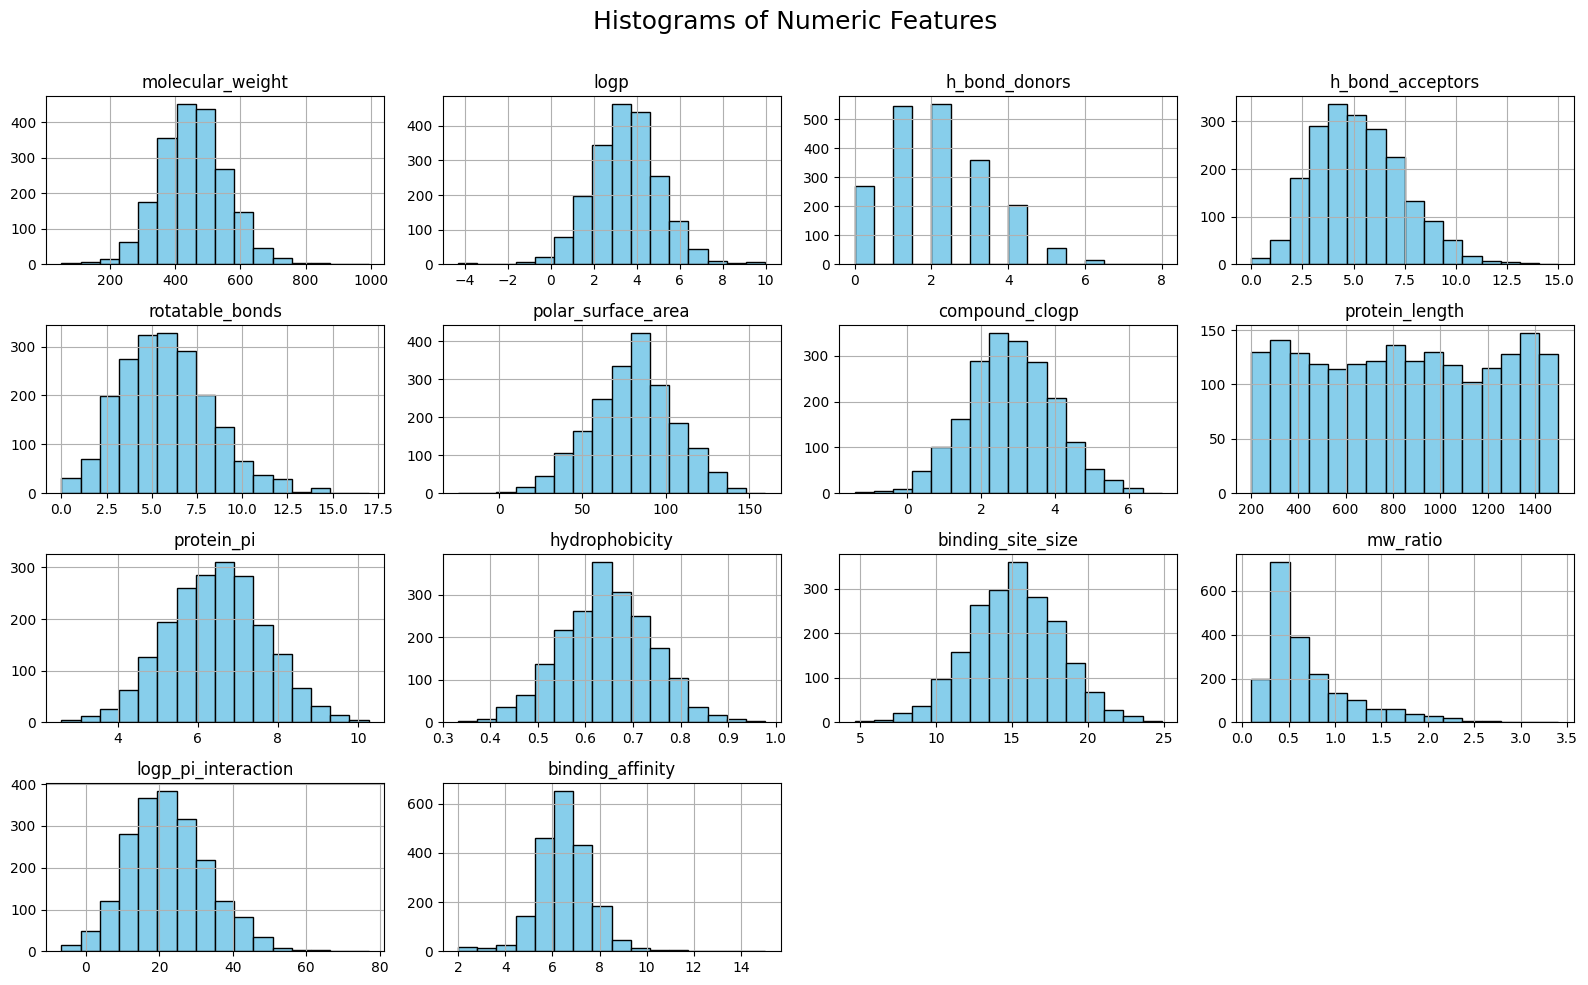

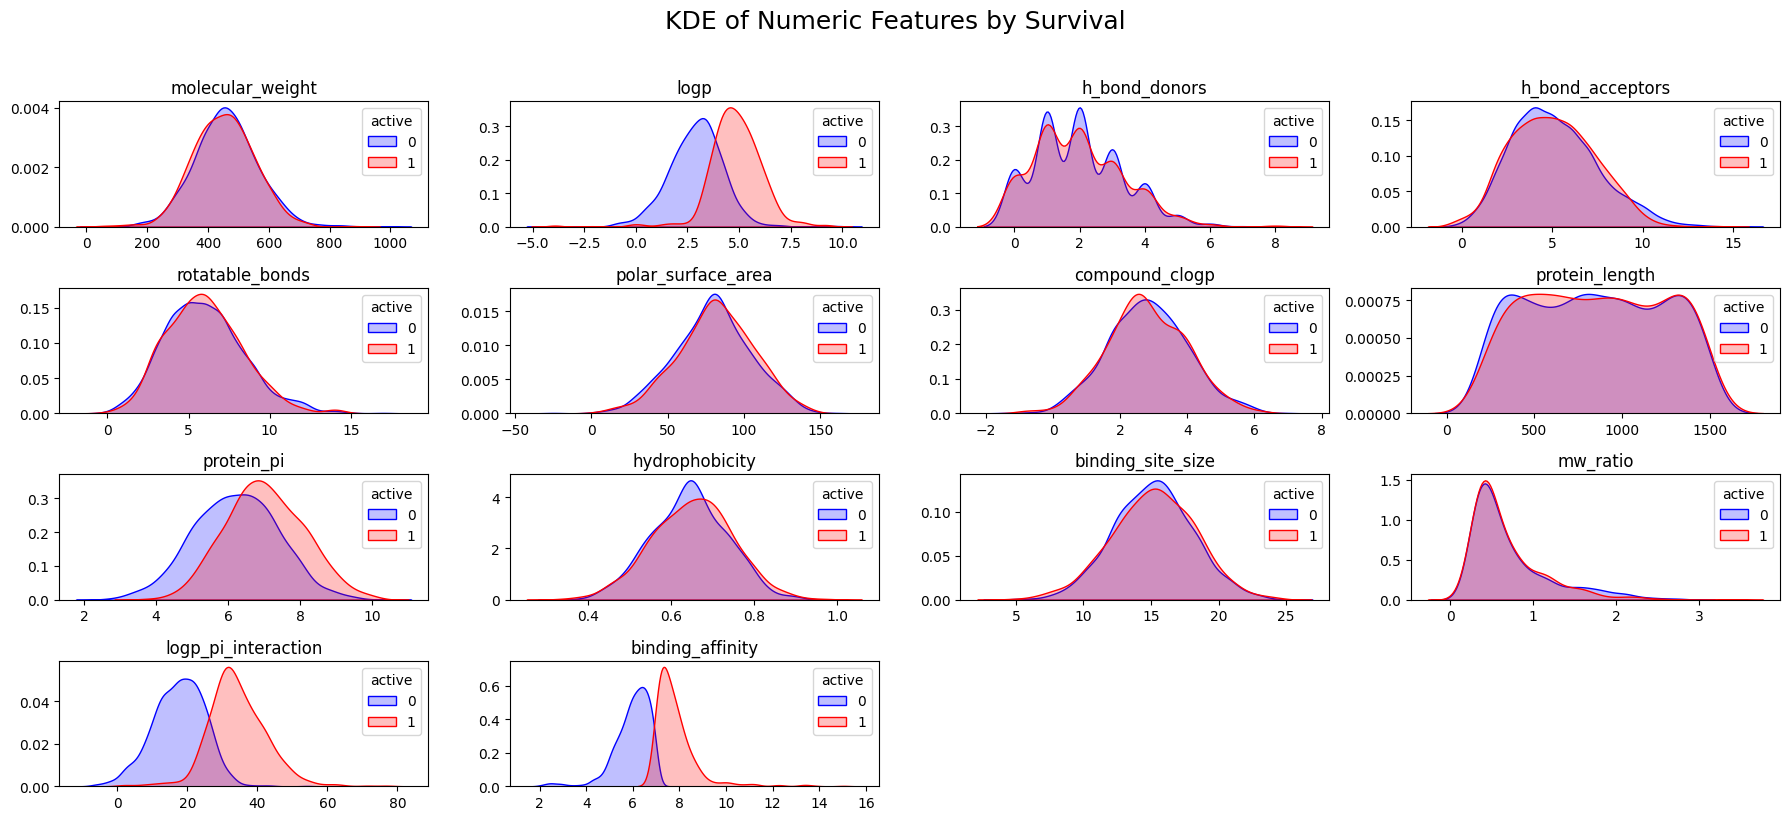

In [100]:
# Histograms for all numerics
import math
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("active")

df[numeric_cols].hist(bins=16, figsize=(16, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

# KDE by target
fig, axes = plt.subplots(math.ceil(len(numeric_cols)/4), 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    [sns.kdeplot(df[df['active']==event][col], fill=True, ax=ax, label=event, color=c)
     for event, c in zip([0,1], ['blue','red'])]
    ax.set_title(col)
    ax.legend(title='active')
    ax.set_xlabel("")
    ax.set_ylabel("")

[ax.axis('off') for ax in axes[len(numeric_cols):]]  # Hide unused axes

fig.suptitle("KDE of Numeric Features by Survival", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

Histograms: most of the features seems to be normally distributed
KDE plots: features are normally distrbuted for both labels of the target values. Interesting to see, that peaks for the logp_pi_interaction, binding_affinity and logp are different for the target values. 

# 5. Exploratory data analysis

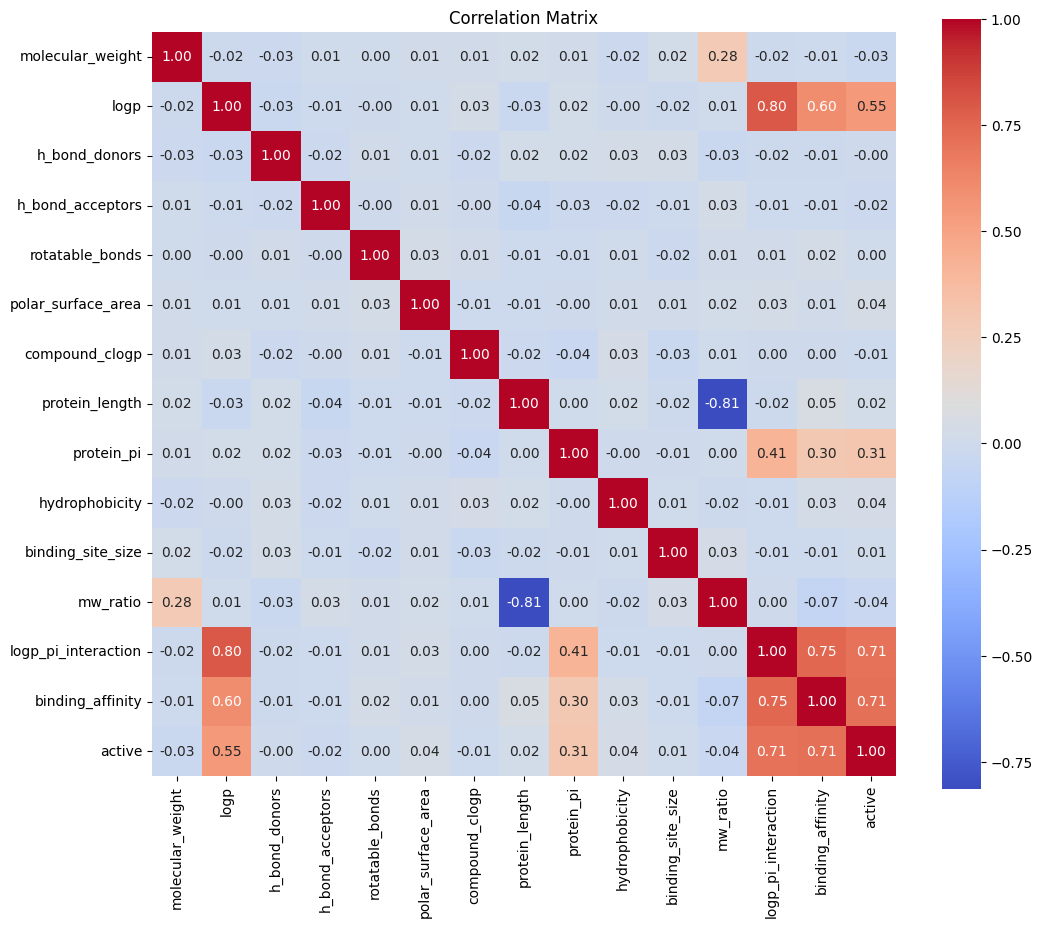

In [101]:
# correlation matrix

# Compute the correlation matrix
corr = df.select_dtypes(include=("int64","float64")).corr()


# Set up the matplotlib figure
plt.figure(figsize=(12, 10))


# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

Correlation analysis shows there is a strong correlation among several numeric features. The target feature correlates well with t he binding affinity, logp_pi_interaction, logp - which biologically makes sense. If a protein has a strong binding affinity, then there is a higher chance that it has an activity on its receptor/another binding protein partner. 


In [102]:
corr

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
molecular_weight,1.000000,-0.019989,-0.025079,0.005201,0.002362,0.014202,0.010893,0.019418,0.012978,-0.021763,0.020076,0.279778,-0.015833,-0.010883,-0.034495
logp,-0.019989,1.000000,-0.032202,-0.010988,-0.003249,0.006816,0.026707,-0.034123,0.017885,-0.003258,-0.017030,0.006265,0.796935,0.596473,0.546438
h_bond_donors,-0.025079,-0.032202,1.000000,-0.023725,0.010718,0.005642,-0.023130,0.020060,0.021960,0.026339,0.026697,-0.033148,-0.015958,-0.014067,-0.001845
h_bond_acceptors,0.005201,-0.010988,-0.023725,1.000000,-0.004702,0.009819,-0.001364,-0.043877,-0.025392,-0.023289,-0.009298,0.028244,-0.011533,-0.010119,-0.021419
rotatable_bonds,0.002362,-0.003249,0.010718,-0.004702,1.000000,0.025339,0.011808,-0.009324,-0.008125,0.005195,-0.023217,0.008329,0.010625,0.024100,0.003230
polar_surface_area,0.014202,0.006816,0.005642,0.009819,0.025339,1.000000,-0.007137,-0.010048,-0.000838,0.014367,0.014204,0.021897,0.025089,0.012936,0.040911
compound_clogp,0.010893,0.026707,-0.023130,-0.001364,0.011808,-0.007137,1.000000,-0.023772,-0.041250,0.031446,-0.028225,0.005167,0.000601,0.000055,-0.011237
protein_length,0.019418,-0.034123,0.020060,-0.043877,-0.009324,-0.010048,-0.023772,1.000000,0.003158,0.015897,-0.018603,-0.814064,-0.018039,0.054114,0.017372
protein_pi,0.012978,0.017885,0.021960,-0.025392,-0.008125,-0.000838,-0.041250,0.003158,1.000000,-0.000551,-0.006212,0.002234,0.412493,0.295579,0.307753
hydrophobicity,-0.021763,-0.003258,0.026339,-0.023289,0.005195,0.014367,0.031446,0.015897,-0.000551,1.000000,0.005487,-0.015538,-0.012727,0.028035,0.035528


# 6. Preprocessing and Machine Learning Modeling

In [103]:
## 6.1 Splitting dataset into test and train set
X = df.drop(columns=["active"])
y = df["active"]

In [104]:
# split the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=42)

print(f"Class balance (train): {y_train.value_counts()}")

Class balance (train): active
0    1253
1     547
Name: count, dtype: int64


!!! The train dataset is imbalanced 0-1/114-486, therefore, synthetic data balancing will be applied. The dataset includes unique ids of proteins, therefore I would rather choose to undersample the "0" class

In [105]:
# Count the number of samples in each class
class_counts = y_train.value_counts()

# Determine the number of samples to keep for the majority class
minority_class_count = class_counts.min()
majority_class = y_train.value_counts().idxmax()

# Randomly sample the majority class to match the minority class count
majority_class_indices = y_train[y_train == majority_class].sample(n=minority_class_count, random_state=42).index

# Combine the undersampled majority class with the minority class
undersampled_indices = y_train[y_train != majority_class].index.union(majority_class_indices)

# Create the undersampled dataset
X_res = X_train.loc[undersampled_indices]
y_res = y_train.loc[undersampled_indices]

# Check the class balance after undersampling
print("Class balance after undersampling:")
print(y_res.value_counts())

Class balance after undersampling:
active
0    547
1    547
Name: count, dtype: int64


In [106]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1800 entries, 485 to 421
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compound_id          1800 non-null   str    
 1   protein_id           1800 non-null   str    
 2   molecular_weight     1800 non-null   float64
 3   logp                 1800 non-null   float64
 4   h_bond_donors        1800 non-null   int64  
 5   h_bond_acceptors     1800 non-null   int64  
 6   rotatable_bonds      1800 non-null   int64  
 7   polar_surface_area   1800 non-null   float64
 8   compound_clogp       1800 non-null   float64
 9   protein_length       1800 non-null   int64  
 10  protein_pi           1800 non-null   float64
 11  hydrophobicity       1800 non-null   float64
 12  binding_site_size    1800 non-null   float64
 13  mw_ratio             1800 non-null   float64
 14  logp_pi_interaction  1800 non-null   float64
 15  binding_affinity     1800 non-null   float64
dtypes: 

In [107]:
# Scale the numeric features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
numeric_cols = X_res.select_dtypes(include=["int64", "float64"]).columns
X_res[numeric_cols] = sc.fit_transform(X_res[numeric_cols])
X_test[numeric_cols] = sc.transform(X_test[numeric_cols])

In [108]:
# encoding the categorical features
from sklearn.preprocessing import OneHotEncoder
categorical_cols = X_res.select_dtypes(include=["object"]).columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_res_encoded = ohe.fit_transform(X_res[categorical_cols])
X_test_encoded = ohe.transform(X_test[categorical_cols])
# Combine the encoded categorical features with the numeric features
X_res_final = np.hstack((X_res[numeric_cols].values, X_res_encoded))
X_test_final = np.hstack((X_test[numeric_cols].values, X_test_encoded))
print(f"Shape of X_res_final: {X_res_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")


Shape of X_res_final: (1094, 1485)
Shape of X_test_final: (200, 1485)


/var/folders/5s/xsxh_mvj2tz0s4q_6f7z01mm0000gn/T/ipykernel_70108/3184624986.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_res.select_dtypes(include=["object"]).columns


## Grid search for the best model and best parameter search

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define models and their hyperparameters
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    }
}

# Perform grid search for each model
best_models = {}
for model_name, model_info in models.items():
    print(f"Running GridSearchCV for {model_name}...")
    grid_search = GridSearchCV(model_info["model"], model_info["params"], cv=5, scoring=["accuracy", "precision", "recall", "f1"], refit="accuracy", n_jobs=-1)
    grid_search.fit(X_res_final, y_res)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best score for {model_name}: {grid_search.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...


/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best score for Logistic Regression: 0.9753
Running GridSearchCV for Random Forest...
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best score for Random Forest: 0.9982
Running GridSearchCV for K-Nearest Neighbors...
Best parameters for K-Nearest Neighbors: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best score for K-Nearest Neighbors: 0.8940
Running GridSearchCV for XGBoost...


/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:13:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:13:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:13:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discover

Best parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best score for XGBoost: 0.9991


/Users/cholponzhakshylykova/Desktop/CZ/Drug-Discovery-Virtual-Screening/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [22:13:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [112]:
# mache confusion matrix and classification report for each model
from sklearn.metrics import classification_report, confusion_matrix
for model_name, model in best_models.items():
    print(f"Evaluating {model_name}...")
    y_pred = model.predict(X_test_final)
    print(f"Classification Report for {model_name}:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {model_name}:\n{confusion_matrix(y_test, y_pred)}\n")

Evaluating Logistic Regression...
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       139
           1       0.98      0.97      0.98        61

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

Confusion Matrix for Logistic Regression:
[[138   1]
 [  2  59]]

Evaluating Random Forest...
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00        61

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix for Random Forest:
[[139   0]
 [  0  61]]

Evaluating K-Nearest Neighbors...
Classification Report for K-Nearest 

# 7. Explainable AI (XAI)

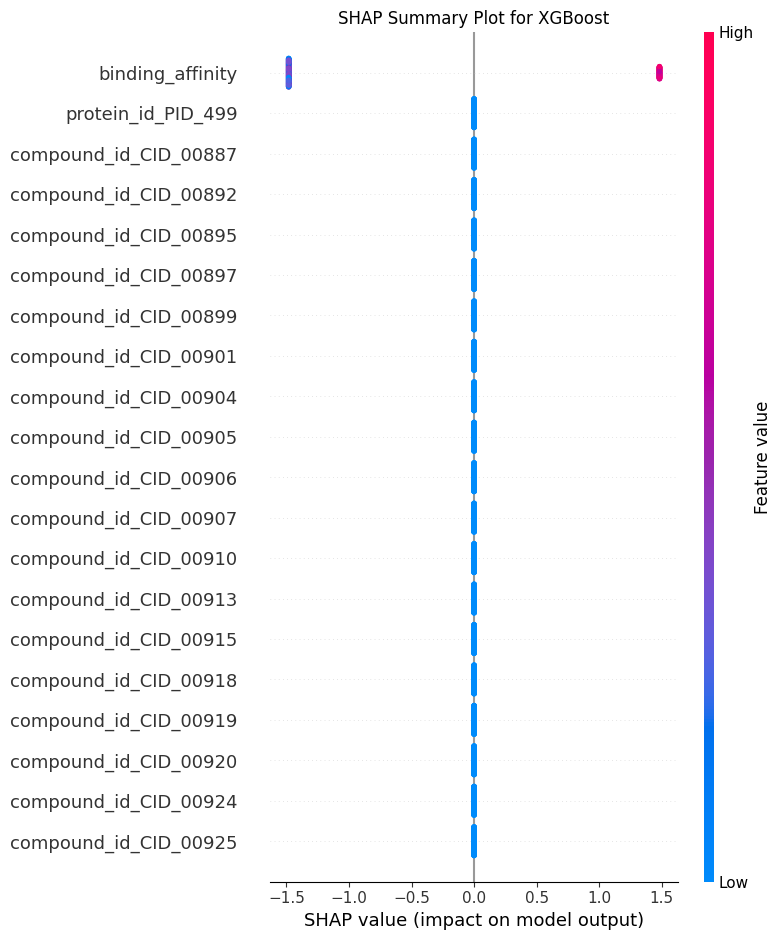

In [118]:
# Explainable AI (XAI)
import shap

# Create a SHAP explainer for the best model which is XGBoost
explainer = shap.TreeExplainer(best_models["XGBoost"])

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_final)

# Ensure feature names are correctly aligned with the transformed dataset
feature_names = list(numeric_cols) + list(ohe.get_feature_names_out(categorical_cols))

# Plot the SHAP summary plot
shap.summary_plot(shap_values, features=X_test_final, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot for XGBoost")
plt.tight_layout()
plt.show()

# 8. Conclusion